# 3 · La varianza y el seed-ensemble (modelo final)

**El problema:** el VAE `recon_prob` gana en promedio (0.559 vs 0.511, soja) pero
con ±0.035 de desvío entre semillas. Para recomendar un modelo hace falta que gane
**siempre**, no según la suerte de la seed.

**La pregunta:** ¿de dónde viene la varianza y cómo se elimina?

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 3.1 · Descartando causas
- **¿El estimador Monte Carlo del score?** No: duplicar las muestras MC (50→100) da un
  resultado idéntico. La varianza viene del **entrenamiento** (cada semilla converge a
  un óptimo local distinto), no del score.
- **¿Falta regularización?** No: el nb. 2 mostró que la regularización pesada *destruye*
  la señal de `recon_prob`.
- **¿Colas pesadas en el decoder (Student-t)?** Tampoco: empeora la media y el desvío
  **sube**. La razón es informativa: las colas pesadas protegen cuando el train está
  *contaminado* con outliers, pero nuestro pipeline ya entrena solo con normales
  curados (nb. 0). No había nada que robustecer:

In [2]:
explib.show(explib.compare_table([
    ("vae_v4_reconprob_lat16","VAE gaussian (ref)"),
    ("vae_studentt_v1","VAE Student-t ν=4")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,VAE gaussian (ref),0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018
1,VAE Student-t ν=4,0.504±0.089,0.687±0.077,0.348±0.080,0.478±0.090,0.237±0.055


## 3.2 · La solución: promediar semillas (seed-ensemble)
Si cada semilla es un óptimo local distinto pero igualmente válido, su ruido
idiosincrático se cancela **promediando los scores** (z-normalizados per-miembro) de N
semillas. El `EnsembleDetector` es agnóstico al modelo base:

In [3]:
explib.describe_architecture("configs/ensemble/vae_seedens_v1.yaml")

Modelo: Ensemble (10 miembros, combine=mean, normalize=zscore)
  Cada miembro:
Modelo: VAE
  Encoder:  54 → 64 → 32 → 16 (latente)
  Decoder:  16 → 32 → 64 → 54
  Score:    recon_prob  (recon_prob = -E[log p(x|z)], pondera por varianza per-feature)
  beta(KL): 1.0

  Optimización: lr=0.001 epochs=300 patience=30 batch=64 n_seeds=—

  n_seeds=3


In [4]:
ens = [("vae_v4_reconprob_lat16","VAE single"),
       ("vae_seedens_v1","VAE seed-ens ×10 (lat16)"),
       ("vae_seedens_deep","VAE seed-ens ×10 (deep)"),
       ("vae_iforest_ens_v1","hetero VAE+IForest")]
explib.show(explib.compare_table(ens, "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,VAE single,0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018
1,VAE seed-ens ×10 (lat16),0.592±0.010,0.738±0.005,0.432±0.003,0.558±0.013,0.297±0.002
2,VAE seed-ens ×10 (deep),0.585±0.007,0.749±0.005,0.519±0.004,0.555±0.010,0.296±0.006
3,hetero VAE+IForest,0.562±0.020,0.730±0.015,0.395±0.025,0.523±0.013,0.270±0.016


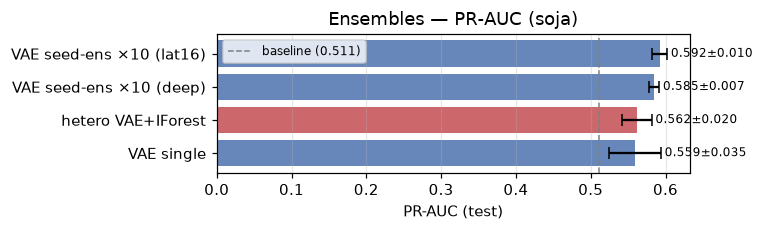

In [5]:
explib.plot_compare(ens, "soja", baseline=0.511, title="Ensembles — PR-AUC (soja)"); plt.show()

**El desvío se desploma (±0.035 → ±0.010) y la media SUBE** (0.559 → 0.592): el
promedio no solo estabiliza, también mejora, porque los errores de cada semilla son
independientes. Con `media − desvío = 0.582 ≫ 0.511`, el seed-ensemble supera al
baseline **también en el peor caso**, en ambos cultivos.

Dos controles que delimitan la conclusión:
- **Hetero-ensemble VAE+IForest**: queda a la altura del VAE single y por debajo del
  seed-ensemble puro — el IForest no aporta señal nueva, solo diluye. Mezclar modelos
  solo suma si el segundo trae información que el primero no tiene.
- **El ensemble no salva una base débil** — mismo tratamiento al AE y al DAE
  (base [64,32] con score MSE):

In [6]:
explib.show(explib.compare_table([
    ("ae_seedens_v1","AE seed-ens ×10 (MSE)"),
    ("dae_seedens_v1","DAE seed-ens ×10 (MSE)"),
    ("vae_seedens_v1","VAE seed-ens ×10 (recon_prob)")], "soja"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,AE seed-ens ×10 (MSE),0.339±0.006,0.611±0.007,0.178±0.026,0.372±0.008,0.135±0.008
1,DAE seed-ens ×10 (MSE),0.413±0.003,0.693±0.002,0.427±0.010,0.462±0.005,0.176±0.008
2,VAE seed-ens ×10 (recon_prob),0.592±0.010,0.738±0.005,0.432±0.003,0.558±0.013,0.297±0.002


El ensemble les elimina la varianza igual… pero la media no acompaña: **el
diferenciador es el score `recon_prob`** (nb. 2), el ensemble solo consolida.

## 3.3 · El modelo elegido: `vae_seedens_v1`
VAE `recon_prob` (lat 16, hidden [64,32], β=1) × 10 semillas. Curva PR y punto de
operación:

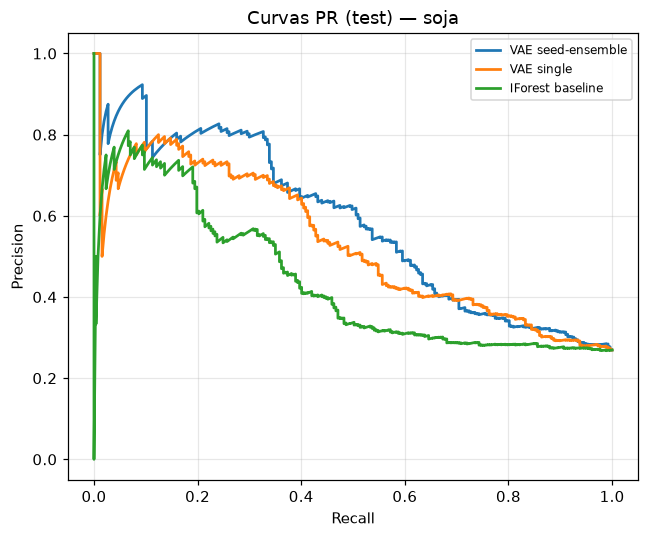

In [7]:
explib.plot_pr_curves([("vae_seedens_v1","VAE seed-ensemble"),
                       ("vae_v4_reconprob_lat16","VAE single"),
                       ("iforest_v2_mf03_n200","IForest baseline")], "soja"); plt.show()

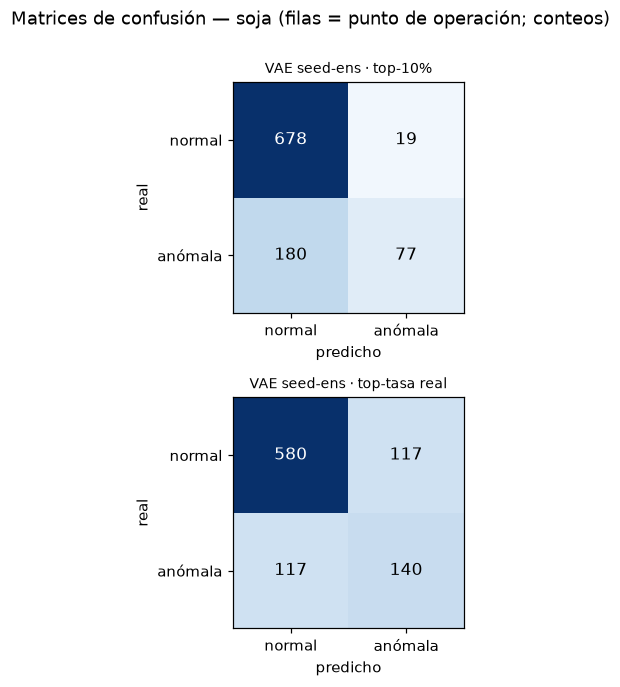

In [8]:
explib.plot_confusion_grid([("vae_seedens_v1", "VAE seed-ens")], "soja"); plt.show()

**Conclusiones del notebook:** la varianza del VAE viene del entrenamiento y se
resuelve con el **ensemble de semillas** (no con más MC, ni regularización, ni Student-t);
el hetero-ensemble y los seed-ensembles de AE/DAE delimitan el resultado: hace falta
**base fuerte (`recon_prob`) + promedio de semillas**. Modelo final del Componente A:
**`vae_seedens_v1` — soja 0.592 ± 0.010, maíz 0.508 ± 0.005**.

**Pero** queda una pregunta incómoda: ¿por qué *ningún* modelo — de familias totalmente
distintas — pasa de ~0.6? **Próximo notebook.**